<a href="https://colab.research.google.com/github/PawaniMekhala/AI-Driven-Student-Dropout-Prediction/blob/main/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [ ]:
# Update path if needed
data_path = "/content/drive/MyDrive/student-dropout-prediction/data/raw/data.csv"
# Load dataset
df = pd.read_csv(data_path, sep=';')
# Show first 5 rows
print("First 2 rows:")
df.head(2)

First 2 rows:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.0,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.0,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate


In [ ]:
# shape
print("Shape:")
display(df.shape)

Shape:


(4424, 37)

In [ ]:
# columns (Confirm that Target column exists)
print("Columns:")
display(df.columns)

Columns:


Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [ ]:
# Fix Column Name Issue (the tab “\t”)
df.columns = df.columns.str.replace('\t','', regex=True)

df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

In [ ]:
# Show basic info (columns, data types, missing values)
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification     

In [ ]:
# Check the data type of Target (This confirms it is categorical text data, not numbers.)
df['Target'].dtype

dtype('O')

In [ ]:
# Find ALL unique values in Target(see what classes exist)
df['Target'].unique()

array(['Dropout', 'Graduate', 'Enrolled'], dtype=object)

In [ ]:
# Count how many students belong to each class
# This tells:
# Class imbalance exists
# Dropout is NOT the majority class
# This justifies SMOTE / class weighting

In [ ]:
df['Target'].value_counts()

,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


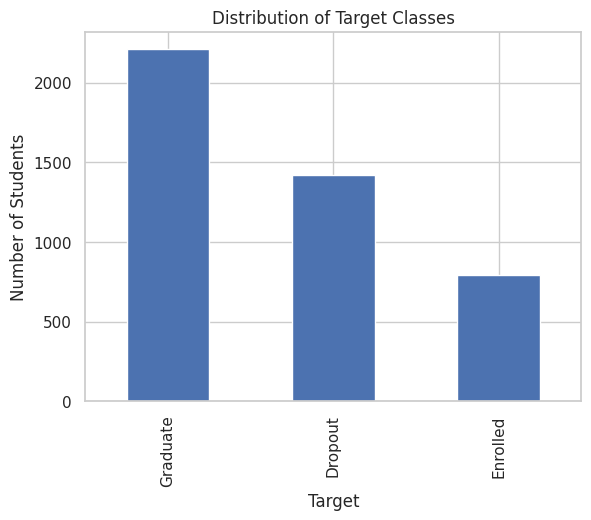

In [ ]:
# Visualize class distribution
import matplotlib.pyplot as plt

df['Target'].value_counts().plot(kind='bar')
plt.title("Distribution of Target Classes")
plt.xlabel("Target")
plt.ylabel("Number of Students")
plt.show()

In [ ]:
# Convert Target into Binary (Dropout vs Non-Dropout)
# 1 – Create binary target
df['Dropout_binary'] = df['Target'].apply(
    lambda x: 1 if x == 'Dropout' else 0
)
# 2 – Verify conversion
df[['Target', 'Dropout_binary']].head(5)

,Target,Dropout_binary
0,Dropout,1
1,Graduate,0
2,Dropout,1
3,Graduate,0
4,Graduate,0


In [ ]:
# Double-check final class balance
df['Dropout_binary'].value_counts()

,count
Dropout_binary,
0,3003
1,1421


In [ ]:
# Check missing values
df.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


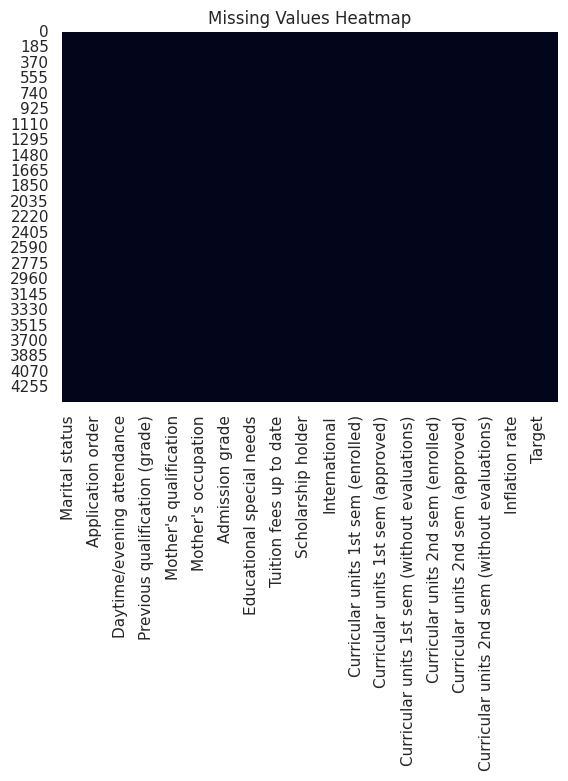

In [ ]:
# Check missing values heatmap
import seaborn as sns

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
# Separate numeric vs categorical columns
categorical_cols = df.select_dtypes(include=['object', 'int64']).columns
numeric_cols = df.select_dtypes(include=['float64']).columns

# categorical_cols = df.select_dtypes(include=['object']).columns
# numeric_cols = df.select_dtypes(include=['int64','float64']).columns

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

print("Categorical columns:", len(categorical_cols))
print("Numeric columns:", len(numeric_cols))

Categorical: Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (without evaluations)', 'Target',
       'Dropout_binary'],
      dtype='object')
Numeric: Ind

In [ ]:
df.groupby('Target')['Admission grade'].mean()
# ONE simple academic comparison (example)
#  Question: Do dropouts have lower grades?

,Admission grade
Target,
Dropout,124.961365
Enrolled,125.534257
Graduate,128.794432


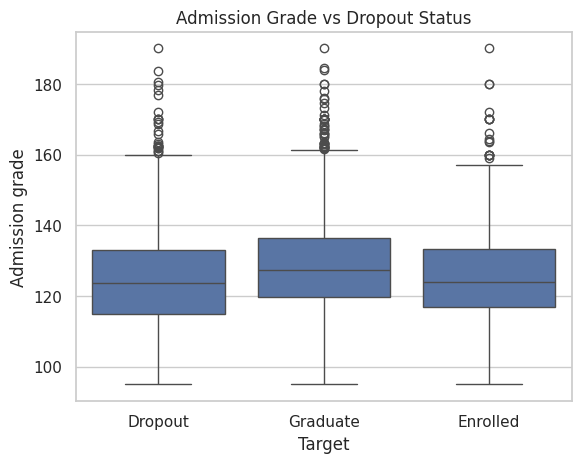

In [ ]:
sns.boxplot(x='Target', y='Admission grade', data=df)
plt.title("Admission Grade vs Dropout Status")
plt.show()

In [ ]:
# ONE simple first-semester comparison
df.groupby('Target')['Curricular units 1st sem (grade)'].mean()
# Shows early academic risk signals

,Curricular units 1st sem (grade)
Target,
Dropout,7.256656
Enrolled,11.125257
Graduate,12.643655


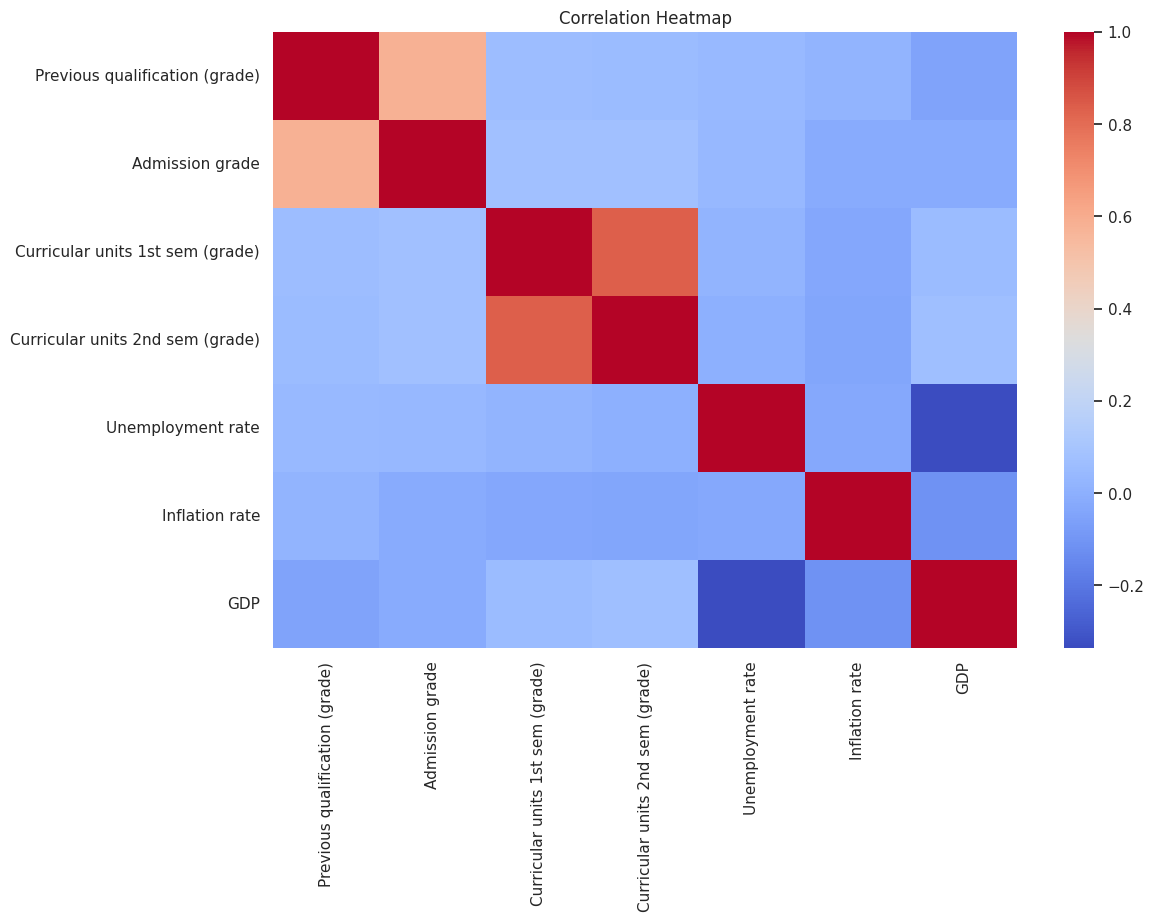

In [ ]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()